# Lab | Text Generation from Shakespeare's Sonnet

This notebook explores the fascinating domain of text generation using a deep learning model trained on Shakespeare's sonnets. 

The objective is to create a neural network capable of generating text sequences that mimic the style and language of Shakespeare.

By utilizing a Recurrent Neural Network (RNN) with Long Short-Term Memory (LSTM) layers, this project aims to demonstrate how a model can learn and replicate the complex patterns of early modern English. 

The dataset used consists of Shakespeare's sonnets, which are preprocessed and tokenized to serve as input for the model.

Throughout this notebook, you will see the steps taken to prepare the data, build and train the model, and evaluate its performance in generating text. 

This lab provides a hands-on approach to understanding the intricacies of natural language processing (NLP) and the potential of machine learning in creative text generation.

Let's import necessary libraries

In [1]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
import tensorflow.keras.utils as ku 
import numpy as np

Let's get the data!

In [2]:
import requests
url = 'https://raw.githubusercontent.com/martin-gorner/tensorflow-rnn-shakespeare/master/shakespeare/sonnets.txt'
resp = requests.get(url)
with open('sonnets.txt', 'wb') as f:
    f.write(resp.content)

data = open('sonnets.txt').read()

corpus = data.lower().split("\n")

Step 1: Initialise a tokenizer and fit it on the corpus variable using .fit_on_texts

In [3]:
# Initialize tokenizer
tokenizer = Tokenizer()

# Fit tokenizer on the corpus
tokenizer.fit_on_texts(corpus)

# Get total words
total_words = len(tokenizer.word_index) + 1
print(f"Total words: {total_words}")

Total words: 3375


In [4]:
tokenizer.word_index

{'and': 1,
 'the': 2,
 'to': 3,
 'of': 4,
 'my': 5,
 'i': 6,
 'in': 7,
 'that': 8,
 'thy': 9,
 'thou': 10,
 'with': 11,
 'for': 12,
 'is': 13,
 'not': 14,
 'love': 15,
 'but': 16,
 'a': 17,
 'me': 18,
 'thee': 19,
 'so': 20,
 'be': 21,
 'as': 22,
 'all': 23,
 'you': 24,
 'his': 25,
 'which': 26,
 'when': 27,
 'it': 28,
 'this': 29,
 'by': 30,
 'your': 31,
 'doth': 32,
 'do': 33,
 'from': 34,
 'on': 35,
 'or': 36,
 'no': 37,
 'then': 38,
 'have': 39,
 'what': 40,
 'are': 41,
 'if': 42,
 'more': 43,
 'mine': 44,
 'their': 45,
 'shall': 46,
 'sweet': 47,
 'time': 48,
 'will': 49,
 'they': 50,
 'beauty': 51,
 'nor': 52,
 'eyes': 53,
 'art': 54,
 'her': 55,
 'heart': 56,
 'yet': 57,
 'o': 58,
 'than': 59,
 'can': 60,
 'should': 61,
 'thine': 62,
 'now': 63,
 'where': 64,
 'make': 65,
 'one': 66,
 'hath': 67,
 'he': 68,
 'fair': 69,
 'still': 70,
 'how': 71,
 'eye': 72,
 'him': 73,
 'like': 74,
 'true': 75,
 'see': 76,
 'am': 77,
 'she': 78,
 'those': 79,
 'though': 80,
 'being': 81,
 'some'

In [5]:
sequences = tokenizer.texts_to_sequences(corpus)

Step 2: Calculate the Vocabulary Size

Let's figure out how many unique words are in your corpus. This will be the size of your vocabulary.

Calculate the length of tokenizer.word_index, add 1 to it and store it in a variable called total_words.

In [6]:
total_words = len(tokenizer.word_index) + 1
print ("Total Words:", total_words)

Total Words: 3375


Create an empty list called input_sequences.

For each sentence in your corpus, convert the text into a sequence of integers using the tokenizer.
Then, generate n-gram sequences from these tokens.

Store the result in the list input_sequences.

In [7]:
# Create input sequences
input_sequences = []

for line in corpus:
    # Convert line to sequence of tokens
    token_list = tokenizer.texts_to_sequences([line])[0]
    
    # Create n-gram sequences
    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)

print(f"Total input sequences: {len(input_sequences)}")
print(f"Example sequence: {input_sequences[0]}")

Total input sequences: 15484
Example sequence: [3, 2]


Calculate the length of the longest sequence in input_sequences. Assign the result to a variable called max_sequence_len.

Now pad the sequences using pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre').
Convert it to a numpy array and assign the result back to our variable called input_sequences.

In [8]:
# Find max sequence length
max_sequence_len = max([len(seq) for seq in input_sequences])
print(f"Max sequence length: {max_sequence_len}")

# Pad sequences
input_sequences = pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre')
print(f"Padded sequences shape: {input_sequences.shape}")

Max sequence length: 11
Padded sequences shape: (15484, 11)


In [9]:
input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_sequence_len,
    padding='pre'
)

input_sequences = np.array(input_sequences)

Prepare Predictors and Labels

Split the sequences into two parts:

- Predictors: All elements from input_sequences except the last one.
- Labels: The last element of each sequence in input_sequences.

In [10]:
X = input_sequences[:, :-1]


In [11]:
labels = input_sequences[:, -1]


One-Hot Encode the Labels :

Convert the labels (which are integers) into one-hot encoded vectors. 

Ensure the length of these vectors matches the total number of unique words in your vocabulary.

Use ku.to_categorical() on labels with num_classes = total_words

Assign the result back to our variable labels.

In [12]:
y = ku.to_categorical(labels, num_classes=total_words)

In [13]:
print(labels.shape)

(15484,)


# Initialize the Model

Start by creating a Sequential model.

Add Layers to the Model:

Embedding Layer: The first layer is an embedding layer. It converts word indices into dense vectors of fixed size (100 in this case). Set the input length to the maximum sequence length minus one, which corresponds to the number of previous words the model will consider when predicting the next word.

Bidirectional LSTM Layer: Add a Bidirectional LSTM layer with 150 units. This layer allows the model to learn context from both directions (past and future) in the sequence. return_sequences=True

Dropout Layer: Add a dropout layer with a rate of 0.2 to prevent overfitting by randomly setting 20% of the input units to 0 during training.

LSTM Layer: Add a second LSTM layer with 100 units. This layer processes the sequence and passes its output to the next layer.

Dense Layer (Intermediate): Add a dense layer with half the total number of words as units, using ReLU activation. A regularization term (L2) is added to prevent overfitting.

Dense Layer (Output): The final dense layer has as many units as there are words in the vocabulary, with a softmax activation function to output a probability distribution over all words.

In [14]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.regularizers import l2

model = Sequential()

# 1) Embedding layer
model.add(
    Embedding(
        input_dim=total_words,      # vocabulary size
        output_dim=100,             # embedding vector size
        input_length=max_sequence_len - 1
    )
)

# 2) Bidirectional LSTM (return sequences for the next LSTM)
model.add(Bidirectional(LSTM(150, return_sequences=True)))

# 3) Dropout
model.add(Dropout(0.2))

# 4) Second LSTM
model.add(LSTM(100))

# 5) Intermediate Dense with L2 regularization
model.add(Dense(total_words // 2, activation='relu', kernel_regularizer=l2(0.01)))

# 6) Output Dense (softmax over vocabulary)
model.add(Dense(total_words, activation='softmax'))



c:\Users\yogan\Documents\JupyterNotebook_ironhack\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


# Compile the Model:

Compile the model using categorical crossentropy as the loss function, the Adam optimizer for efficient training, and accuracy as the metric to evaluate during training.

In [15]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Print Model Summary:

Use model.summary() to print a summary of the model, which shows the layers, their output shapes, and the number of parameters.

In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# Now train the model for 50 epochs and assign it to a variable called history.

Training the model with 50 epochs should get you around 40% accuracy.

You can train the model for as many epochs as you like depending on the time and computing constraints you are facing. Ideally train it for a larger amount of epochs than 50.

That way you will get better text generation at the end.

However, dont waste your time.

In [18]:
history = model.fit(
    X,
    y,
    epochs=50,
    verbose=1
)

Epoch 1/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 31s 55ms/step - accuracy: 0.0212 - loss: 6.9078
Epoch 2/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 27s 56ms/step - accuracy: 0.0214 - loss: 6.5083
Epoch 3/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 27s 55ms/step - accuracy: 0.0245 - loss: 6.4085
Epoch 4/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 26s 54ms/step - accuracy: 0.0294 - loss: 6.2876
Epoch 5/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 26s 54ms/step - accuracy: 0.0351 - loss: 6.2030
Epoch 6/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 26s 53ms/step - accuracy: 0.0361 - loss: 6.1348
Epoch 7/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 26s 53ms/step - accuracy: 0.0392 - loss: 6.0703
Epoch 8/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 25s 52ms/step - accuracy: 0.0410 - loss: 6.0044
Epoch 9/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 25s 52ms/step - accuracy: 0.0470 - loss: 5.9294
Epoch 10/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 26s 53ms/step - accuracy: 0.0517 - loss: 5.8438
Epoch 11/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 26s 54ms/step - accuracy: 0.0582 - loss: 5.7465
Epoch 12/50
484/484 ━━━━━━━━━━

# Use plt from matplotlib to plot the training accuracy over epochs and the loss over epochs

First you will have to get the accuracy and loss data over epochs, you can do this by using methods on your model.

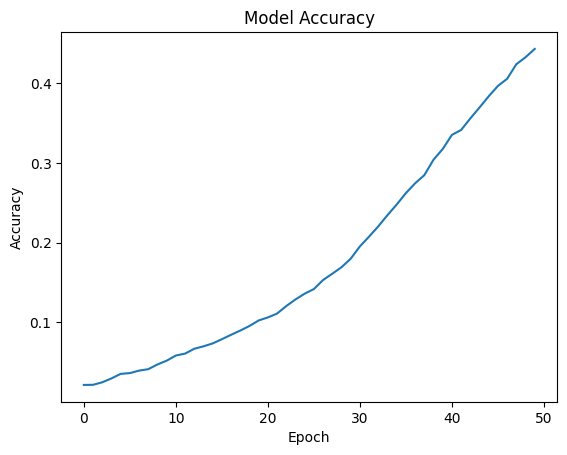

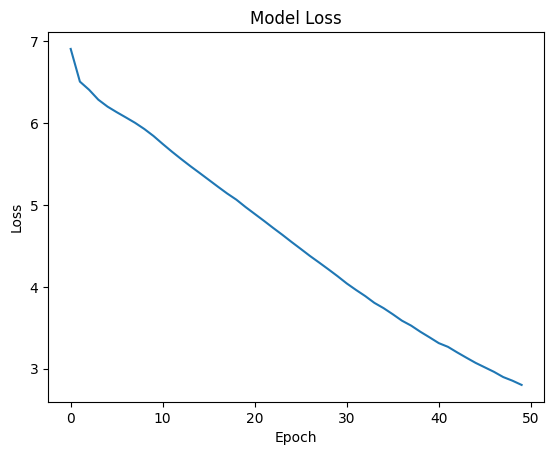

In [20]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.figure()
plt.plot(history.history['accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

# Plot Loss
plt.figure()
plt.plot(history.history['loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

# Generate text with the model based on a seed text

Now you will create two variables :

- seed_text = 'Write the text you want the model to use as a starting point to generate the next words'
- next_words = number_of_words_you_want_the_model_to_generate

Please change number_of_words_you_want_the_model_to_generate by an actual integer.

In [21]:
seed_text = "shall i compare thee"
next_words = 20   # generate 20 new words

Now create a loop that runs based on the next_words variable and generates new text based on your seed_text input string. Print the full text with the generated text at the end.

This time you dont get detailed instructions.

Have fun!

In [22]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

for _ in range(next_words):
    
    # Convert seed text to token sequence
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    
    # Pad sequence to expected input length
    token_list = pad_sequences([token_list],
                               maxlen=max_sequence_len - 1,
                               padding='pre')
    
    # Predict probability distribution
    predicted_probs = model.predict(token_list, verbose=0)
    
    # Get index of highest probability word
    predicted_index = np.argmax(predicted_probs, axis=1)[0]
    
    # Convert index back to word
    output_word = ""
    for word, index in tokenizer.word_index.items():
        if index == predicted_index:
            output_word = word
            break
    
    # Append predicted word to seed text
    seed_text += " " + output_word

print(seed_text)

shall i compare thee with thy love shines so level to thee more strong hours in me new lie from me are thee for


Experiment with at least 3 different seed_text strings and see what happens!

In [23]:
seed_text = "my heart is"
next_words = 25

In [24]:
for _ in range(next_words):
    
    # Convert seed text to token sequence
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    
    # Pad sequence to expected input length
    token_list = pad_sequences([token_list],
                               maxlen=max_sequence_len - 1,
                               padding='pre')
    
    # Predict probability distribution
    predicted_probs = model.predict(token_list, verbose=0)
    
    # Get index of highest probability word
    predicted_index = np.argmax(predicted_probs, axis=1)[0]
    
    # Convert index back to word
    output_word = ""
    for word, index in tokenizer.word_index.items():
        if index == predicted_index:
            output_word = word
            break
    
    # Append predicted word to seed text
    seed_text += " " + output_word

print(seed_text)

my heart is yet thy love to this art bright ' too leaves ' did express'd ' before so beauteous far joy love eye of every heart will


In [25]:
seed_text = "eternal night whispers"
next_words = 25

In [26]:
for _ in range(next_words):
    
    # Convert seed text to token sequence
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    
    # Pad sequence to expected input length
    token_list = pad_sequences([token_list],
                               maxlen=max_sequence_len - 1,
                               padding='pre')
    
    # Predict probability distribution
    predicted_probs = model.predict(token_list, verbose=0)
    
    # Get index of highest probability word
    predicted_index = np.argmax(predicted_probs, axis=1)[0]
    
    # Convert index back to word
    output_word = ""
    for word, index in tokenizer.word_index.items():
        if index == predicted_index:
            output_word = word
            break
    
    # Append predicted word to seed text
    seed_text += " " + output_word

print(seed_text)

eternal night whispers to catch the world without veins find too love new ' so destroys to the way sail to thee still taken prove me writ before


In [27]:
seed_text = "when in disgrace with fortune"
next_words = 25

In [28]:
for _ in range(next_words):
    
    # Convert seed text to token sequence
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    
    # Pad sequence to expected input length
    token_list = pad_sequences([token_list],
                               maxlen=max_sequence_len - 1,
                               padding='pre')
    
    # Predict probability distribution
    predicted_probs = model.predict(token_list, verbose=0)
    
    # Get index of highest probability word
    predicted_index = np.argmax(predicted_probs, axis=1)[0]
    
    # Convert index back to word
    output_word = ""
    for word, index in tokenizer.word_index.items():
        if index == predicted_index:
            output_word = word
            break
    
    # Append predicted word to seed text
    seed_text += " " + output_word

print(seed_text)

when in disgrace with fortune and decay bow esteem'd new new virtue far for the heart of thee one one hour good eyes seen seen wanting eye are torn what
